<a href="https://colab.research.google.com/github/wilmar-barragan/Deep-Learning-week14-Actividad-14-Aplicaci-n-de-los-Conceptos-de-GANs/blob/main/Actividad_14_Aplicaci%C3%B3n_de_los_Conceptos_de_GANs_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  Implementación de una Red Generativa Adversaria (GAN) con MNIST

###  ¿Qué es una GAN y cómo funciona?
Una **GAN** es un marco de aprendizaje profundo compuesto por dos redes neuronales que compiten entre sí en un juego de suma cero (minimax):
1. **Generador (`G`)**: Recibe un vector de ruido aleatorio y aprende a transformarlo en imágenes sintéticas que imiten la distribución real del dataset.
2. **Discriminador (`D`)**: Actúa como un clasificador binario. Recibe imágenes reales y falsas, y debe distinguir cuál es cuál.

Durante el entrenamiento, `G` intenta engañar a `D`, mientras `D` mejora su capacidad de detección. Esta competencia iterativa fuerza a `G` a refinar sus salidas hasta generar datos indistinguibles de los reales.

In [18]:
# 📦 Importación de librerías y configuración del entorno
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os
import time

# Fijar semillas para reproducibilidad
tf.random.set_seed(42)
np.random.seed(42)

print(f"TensorFlow Version: {tf.__version__}")
print("GPU disponible:", "Sí" if tf.config.list_physical_devices('GPU') else "No (se usará CPU)")

TensorFlow Version: 2.20.0
GPU disponible: Sí


### Carga y Preparación del Dataset
Utilizaremos **MNIST** por su baja complejidad y rapidez de entrenamiento.
- Se normalizan los píxeles al rango `[-1, 1]` para coincidir con la activación `tanh` del generador.
- Se usa `tf.data.Dataset` para un flujo de datos eficiente en memoria.

In [19]:
# Carga del dataset MNIST
(train_images, _), (_, _) = tf.keras.datasets.mnist.load_data()

# Redimensionar y normalizar a [-1, 1]
train_images = train_images.reshape(train_images.shape[0], 28, 28, 1).astype('float32')
train_images = (train_images - 127.5) / 127.5

BUFFER_SIZE = 60000
BATCH_SIZE = 64

# Crear pipeline de datos optimizado
train_dataset = tf.data.Dataset.from_tensor_slices(train_images) \
    .shuffle(BUFFER_SIZE).batch(BATCH_SIZE)

print(f"Shape del dataset: {train_images.shape}")
print(f"Batch size: {BATCH_SIZE}")

Shape del dataset: (60000, 28, 28, 1)
Batch size: 64


### Arquitectura del Generador
Convierte un vector latente de 100 dimensiones en una imagen `28x28x1`.
- Usa `Dense` → `Reshape` para iniciar el volumen espacial.
- `Conv2DTranspose` realiza el *upsampling* progresivo.
- `BatchNormalization` estabiliza el entrenamiento.
- `tanh` en la salida garantiza valores en `[-1, 1]`.

In [20]:
def make_generator_model():
    model = tf.keras.Sequential([
        tf.keras.layers.Dense(7*7*256, use_bias=False, input_shape=(100,)),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.LeakyReLU(),

        tf.keras.layers.Reshape((7, 7, 256)),

        tf.keras.layers.Conv2DTranspose(128, (5, 5), strides=(2, 2), padding='same', use_bias=False),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.LeakyReLU(),

        tf.keras.layers.Conv2DTranspose(64, (5, 5), strides=(2, 2), padding='same', use_bias=False),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.LeakyReLU(),

        tf.keras.layers.Conv2D(1, (7, 7), padding='same', use_bias=False, activation='tanh')
    ])
    return model

generator = make_generator_model()
generator.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_7 (Dense)                 │ (None, 12544)          │     1,254,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 12544)          │        50,176 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_18 (LeakyReLU)      │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_4 (Reshape)             │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_8              │ (None, 14, 14, 128)    │       819,200 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 14, 14, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_19 (LeakyReLU)      │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_9              │ (None, 28, 28, 64)     │       204,800 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 28, 28, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_20 (LeakyReLU)      │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 28, 28, 1)      │         3,136 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,332,480 (8.90 MB)

 Trainable params: 2,307,008 (8.80 MB)

 Non-trainable params: 25,472 (99.50 KB)

### Arquitectura del Discriminador
Clasificador convolucional que reduce la imagen a una probabilidad `[0, 1]`.
- `Conv2D` con `strides=2` actúa como downsampling.
- `LeakyReLU` permite flujo de gradiente para valores negativos (evita "neuronas muertas").
- `Dropout` regulariza y previene sobreajuste rápido.

In [21]:
def make_discriminator_model():
    model = tf.keras.Sequential([
        tf.keras.layers.Conv2D(64, (5, 5), strides=(2, 2), padding='same', input_shape=[28, 28, 1]),
        tf.keras.layers.LeakyReLU(),
        tf.keras.layers.Dropout(0.3),

        tf.keras.layers.Conv2D(128, (5, 5), strides=(2, 2), padding='same'),
        tf.keras.layers.LeakyReLU(),
        tf.keras.layers.Dropout(0.3),

        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])
    return model

discriminator = make_discriminator_model()
discriminator.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_11 (Conv2D)              │ (None, 14, 14, 64)     │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_21 (LeakyReLU)      │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 7, 7, 128)      │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_22 (LeakyReLU)      │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │         6,273 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 212,865 (831.50 KB)

 Trainable params: 212,865 (831.50 KB)

 Non-trainable params: 0 (0.00 B)

### Funciones de Pérdida, Optimizadores y Paso de Entrenamiento
- **Pérdida**: `BinaryCrossentropy`. `D` quiere maximizar su acierto, `G` quiere minimizar el error de `D` cuando recibe imágenes falsas.
- **`@tf.function`**: Compila el paso de entrenamiento en grafo estático, acelerando significativamente la ejecución en Colab.
- Se calculan gradientes por separado para evitar que se anulen entre sí.

In [22]:
# Definición de la función de pérdida
cross_entropy = tf.keras.losses.BinaryCrossentropy()

def discriminator_loss(real_output, fake_output):
    real_loss = cross_entropy(tf.ones_like(real_output), real_output)
    fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)
    return real_loss + fake_loss

def generator_loss(fake_output):
    # El generador quiere que D clasifique sus imágenes como "reales" (1)
    return cross_entropy(tf.ones_like(fake_output), fake_output)

# Optimizadores con tasa de aprendizaje conservadora para estabilidad
generator_optimizer = tf.keras.optimizers.Adam(1e-4)
discriminator_optimizer = tf.keras.optimizers.Adam(1e-4)

@tf.function
def train_step(images):
    noise = tf.random.normal([BATCH_SIZE, 100])

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        generated_images = generator(noise, training=True)

        real_output = discriminator(images, training=True)
        fake_output = discriminator(generated_images, training=True)

        gen_loss = generator_loss(fake_output)
        disc_loss = discriminator_loss(real_output, fake_output)

    gradients_of_generator = gen_tape.gradient(gen_loss, generator.trainable_variables)
    gradients_of_discriminator = disc_tape.gradient(disc_loss, discriminator.trainable_variables)

    generator_optimizer.apply_gradients(zip(gradients_of_generator, generator.trainable_variables))
    discriminator_optimizer.apply_gradients(zip(gradients_of_discriminator, discriminator.trainable_variables))

    return gen_loss, disc_loss

### Ejecución del Entrenamiento y Visualización
- Se ejecutarán **15 épocas** (suficiente para observar evolución sin saturar recursos).
- Cada 5 épocas se guardarán y visualizarán 16 imágenes generadas a partir del mismo vector de ruido semilla.
- Se monitorean las pérdidas de ambos modelos para detectar inestabilidad o colapso de modo.

🟢 Iniciando entrenamiento de la GAN...
⏱️ Época 1/20 | Gen Loss: 1.0679 | Disc Loss: 1.1037 | Tiempo: 33.33s
⏱️ Época 2/20 | Gen Loss: 0.8376 | Disc Loss: 1.2849 | Tiempo: 28.33s
⏱️ Época 3/20 | Gen Loss: 0.7855 | Disc Loss: 1.3288 | Tiempo: 28.19s
⏱️ Época 4/20 | Gen Loss: 0.7802 | Disc Loss: 1.3310 | Tiempo: 28.61s


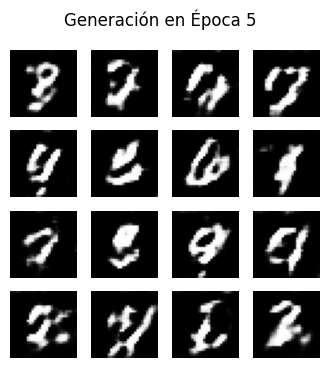

⏱️ Época 5/20 | Gen Loss: 0.8302 | Disc Loss: 1.2806 | Tiempo: 29.14s
⏱️ Época 6/20 | Gen Loss: 0.8917 | Disc Loss: 1.2359 | Tiempo: 28.46s
⏱️ Época 7/20 | Gen Loss: 0.9535 | Disc Loss: 1.1884 | Tiempo: 28.59s
⏱️ Época 8/20 | Gen Loss: 0.9451 | Disc Loss: 1.1906 | Tiempo: 28.50s
⏱️ Época 9/20 | Gen Loss: 0.8880 | Disc Loss: 1.2482 | Tiempo: 28.48s


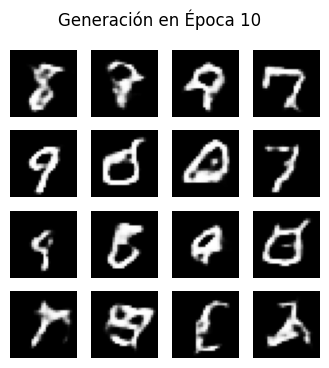

⏱️ Época 10/20 | Gen Loss: 0.8333 | Disc Loss: 1.2930 | Tiempo: 28.76s
⏱️ Época 11/20 | Gen Loss: 0.9335 | Disc Loss: 1.2393 | Tiempo: 28.50s
⏱️ Época 12/20 | Gen Loss: 0.8353 | Disc Loss: 1.2925 | Tiempo: 28.51s
⏱️ Época 13/20 | Gen Loss: 0.8524 | Disc Loss: 1.2807 | Tiempo: 28.54s
⏱️ Época 14/20 | Gen Loss: 0.8223 | Disc Loss: 1.3014 | Tiempo: 28.55s


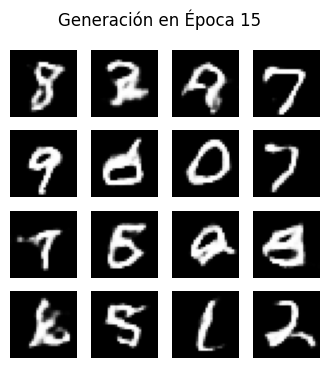

⏱️ Época 15/20 | Gen Loss: 0.8339 | Disc Loss: 1.2950 | Tiempo: 28.80s
⏱️ Época 16/20 | Gen Loss: 0.8296 | Disc Loss: 1.2940 | Tiempo: 28.51s
⏱️ Época 17/20 | Gen Loss: 0.8386 | Disc Loss: 1.2921 | Tiempo: 28.65s
⏱️ Época 18/20 | Gen Loss: 0.8117 | Disc Loss: 1.3050 | Tiempo: 28.52s
⏱️ Época 19/20 | Gen Loss: 0.8310 | Disc Loss: 1.3029 | Tiempo: 28.49s


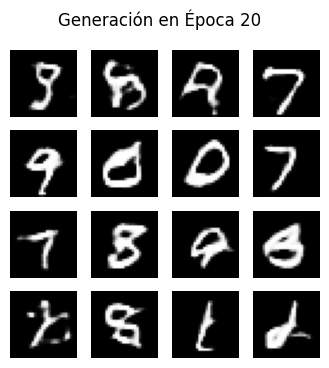

⏱️ Época 20/20 | Gen Loss: 0.8308 | Disc Loss: 1.2993 | Tiempo: 28.71s


In [23]:
EPOCHS = 20
num_examples_to_generate = 16
seed = tf.random.normal([num_examples_to_generate, 100])

def generate_and_save_images(model, epoch, test_input):
    predictions = model(test_input, training=False)
    fig = plt.figure(figsize=(4, 4))
    for i in range(predictions.shape[0]):
        plt.subplot(4, 4, i+1)
        plt.imshow((predictions[i, :, :, 0] + 1) / 2.0, cmap='gray')
        plt.axis('off')
    plt.suptitle(f'Generación en Época {epoch}')
    plt.show()

def train(dataset, epochs):
    for epoch in range(epochs):
        start = time.time()
        gen_losses = []
        disc_losses = []

        for image_batch in dataset:
            g_loss, d_loss = train_step(image_batch)
            gen_losses.append(g_loss)
            disc_losses.append(d_loss)

        # Visualización periódica
        if (epoch + 1) % 5 == 0:
            generate_and_save_images(generator, epoch + 1, seed)

        print(f'⏱️ Época {epoch+1}/{epochs} | '
              f'Gen Loss: {np.mean(gen_losses):.4f} | '
              f'Disc Loss: {np.mean(disc_losses):.4f} | '
              f'Tiempo: {time.time()-start:.2f}s')

print("🟢 Iniciando entrenamiento de la GAN...")
train(train_dataset, EPOCHS)

### Análisis de Resultados y Conclusiones Técnicas

#### 🔹 Dificultades observadas
- **Inestabilidad inicial**: Durante las primeras épocas, el discriminador suele dominar rápidamente, provocando que las pérdidas del generador se estanquen o oscilen. Esto es típico en GANs vanilla por el desbalance de capacidad entre redes.
- **Artefactos y bordes difusos**: Las imágenes generadas muestran contornos reconocibles pero con ruido estructural y falta de nitidez en los trazos, consecuencia de usar solo 20 épocas y una arquitectura básica.
- **Colapso de modo parcial**: En algunos lotes, el generador tiende a producir dígitos similares (ej. muchos `1` o `0`), indicando que aún no ha explorado completamente el espacio latente.

#### 🔹 Posibles mejoras
1. **WGAN-GP o Hinge Loss**: Reemplazar la pérdida de entropía cruzada por Earth Mover's Distance estabiliza el entrenamiento y reduce drásticamente el colapso de modo.
2. **Spectral Normalization**: Aplicar normalización espectral en las capas convolucionales del discriminador controla el Lipschitz constant y suaviza la convergencia.
3. **Aumento de épocas y dataset**: Entrenar por 50-100 épocas o migrar a Fashion-MNIST/CIFAR-10 permitiría observar la evolución hacia texturas y formas más complejas.
4. **Ajuste de learning rates**: Usar un `lr_D > lr_G` en fases tempranas evita que el discriminador se vuelva demasiado fuerte demasiado rápido.

#### 🔹 Aprendizajes técnicos
- Se comprendió la naturaleza **adversarial y no supervisada** de las GANs: no hay etiquetas target para el generador; su "profesor" es el propio discriminador.
- La importancia del **equilibrio dinámico**: una GAN no converge a un mínimo global, sino a un punto de equilibrio de Nash donde ambas pérdidas se estabilizan.
- El entrenamiento es altamente sensible a hiperparámetros, arquitectura y normalización, lo que exige monitoreo constante de métricas y visualización intermedia.